In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
import torch.nn.functional as F

from tokenizers.models import BPE
from tokenizers import Tokenizer
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing

In [2]:
from pathlib import Path

In [3]:
path = Path("/kaggle/input/datasets/phnguyencs/chinese-vi/dataset")

In [4]:
train_path = path / "train"
public_path =path / "public_test"
private_path = path / "private_test"

In [5]:
zh, vi = [], []
with open(train_path / "train.zh", "r", encoding="utf-8") as f:
    zh = f.read().splitlines()

with open(train_path / "train.vi", "r", encoding="utf-8") as f:
    vi = f.read().splitlines()

print(len(zh), len(vi))
for i in range(5):
    print(zh[i], vi[i])

32061 32061
我 会 给 您 拿 一些 。 Tôi sẽ mang cho bạn một_ít . 
如果 你 还 有 什么 需要 的 就 告诉 我 。 Nếu bạn cần điều gì khác hãy cho tôi biết . 
不用 担心 那件 事 。 Đừng lo_lắng về điều đó . 
我 要 买 它 你 不 需要 把 它 包 起来 。 Tôi sẽ mang nó và bạn không cần phải gói nó lại . 
你 改变 吗 ？ Bạn thay_đổi không ? 


In [6]:
import pandas as pd

df= pd.DataFrame({
    "zh": zh,
    "vi": vi
}
)

In [7]:
df.sample(5)

,zh,vi
15149,我 想 推荐 这个 。,Tôi muốn giới_thiệu cái này .
2027,好 点 的 话 要 花 多 长 时间 ？,Làm tốt hơn sẽ mất bao_lâu ?
26400,我 爸爸 在 银行 工作 ， 妈妈 是 家庭主妇 。,"ba tôi làm_việc ở ngân_hàng , má tôi lo việc n..."
16696,我 感觉 浑身 没劲 。,Tôi cảm_thấy lười_biếng .
2925,雇个 导游 一 天 多少 钱 ？,Tốn chi_phí bao_nhiêu để thuê một hướng_dẫn_vi...


## Tokenizer

In [8]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

In [9]:
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-zh-vi")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/750k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/766k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [10]:
tokenizer.bos_token_id

In [11]:
encoded = tokenizer("Tôi tin rằng tôi đúng .", return_tensors="pt")

In [12]:
encoded

{'input_ids': tensor([[  831, 20447,   127,     5,   121,  1845,     5,  2810, 64336,   130,
          1135,     5,   121, 20447,   127,     5, 48358,   130,  1135,     5,
             2,     0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

## Loading Data 

In [13]:
MAX_LEN = 25

In [14]:
class CustomDataset(Dataset):
    def __init__(self, zh, vi, tokenizer):
        self.zh = zh
        self.vi = vi
        self.tokenizer = tokenizer
    def __len__(self) :
       return len(self.zh) 
    def __getitem__(self,idx):
        zh, vi = self.zh[idx], self.vi[idx]
        inputs = self.tokenizer(
            zh, text_target=vi, padding="max_length",max_length=MAX_LEN,
            truncation=True, return_tensors="pt"
        )
        return{
            "input_ids": inputs.input_ids.squeeze(0),
            "attention_mask": inputs.attention_mask.squeeze(0),
            "labels": inputs.labels.squeeze(0)
            
        }


In [15]:
df_train = df.sample(int(0.95 * len(df)), random_state=42)
df_val = df.drop(index=df_train.index)
len(df_train), len(df_val)

(30457, 1604)

In [16]:
train_data = CustomDataset(df_train['zh'].tolist(), df_train['vi'].tolist(), 
                           tokenizer)
val_data = CustomDataset(df_val['zh'].tolist(), df_val['vi'].tolist(), 
                           tokenizer)

In [17]:
train_data[10]

{'input_ids': tensor([   41,  4136,     5,  3716,  8513,     5,  4197,     5,   654,  1301,
             5,  2059,  1056,     5,  2289,     5,    69,     0, 65000, 65000,
         65000, 65000, 65000, 65000, 65000]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0]),
 'labels': tensor([   16,   506,   684,    29,  3800,    89,    25,   249,     5,     2,
             0, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000,
         65000, 65000, 65000, 65000, 65000])}

In [18]:
BATCH_SIZE = 128
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

## Model

In [21]:
backbone = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-zh-vi")

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [22]:
backbone

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(65001, 512, padding_idx=65000)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(65001, 512, padding_idx=65000)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [ ]:
# class NMT(nn.Module):
#     def __init__(self, dim, nhead, size, dropout, ffn, num_encoders, num_decoders):
#         super().__init__()
#         self.scale = math.sqrt(dim)
#         self.embedd = nn.Embedding(size, dim)
#         self.encoder = nn.ModuleList(
#             Encoder(dim, nhead, ffn, dropout) for _ in range(num_encoders)
#         )
#         self.decoder = nn.ModuleList(
#             Decoder(dim, nhead, ffn, dropout) for _ in range(num_decoders)
#         )
#         self.dropout = nn.Dropout(dropout)
#         self.norm = RMSNorm(dim)
#         self.head=  nn.Linear(dim, size, bias= False)
#     def forward(self, src, src_key_padding_mask,
#                 tgt, tgt_mask, tgt_key_padding_mask):
#         src = self.dropout(self.embedd(src) * self.scale)
#         memory = src
#         for layer in self.encoder:
#             memory = layer(memory, src_key_padding_mask)
        
#         tgt = self.dropout(self.embedd(tgt) * self.scale)
#         for layer in self.decoder:
#             tgt = layer(memory, src_key_padding_mask, tgt, tgt_mask, tgt_key_padding_mask)
#         out = self.head(self.norm(tgt))
#         return out.permute(0, 2, 1)

In [ ]:
# DIM = 768
# NHEAD = 6
# SIZE = 8000
# NUM_ENCODERS = 8
# NUM_DECODERS = 8
# FFN = 3072
# DROPOUT = 0.2

In [ ]:
# model = NMT(DIM, NHEAD, SIZE, DROPOUT, FFN, NUM_ENCODERS, NUM_DECODERS )

In [23]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
backbone = backbone.to(DEVICE)

In [24]:
total_params = 0
for p in backbone.parameters():
    total_params += p.numel()
print(total_params)

144504320


In [25]:
backbone.config

MarianConfig {
  "activation_dropout": 0.0,
  "activation_function": "swish",
  "add_bias_logits": false,
  "add_final_layer_norm": false,
  "architectures": [
    "MarianMTModel"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classif_dropout": 0.0,
  "classifier_dropout": 0.0,
  "d_model": 512,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 2048,
  "decoder_layerdrop": 0.0,
  "decoder_layers": 6,
  "decoder_start_token_id": 65000,
  "decoder_vocab_size": 65001,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 8,
  "encoder_ffn_dim": 2048,
  "encoder_layerdrop": 0.0,
  "encoder_layers": 6,
  "eos_token_id": 0,
  "extra_pos_embeddings": 65001,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "init_std": 0.02,
  "is_decoder": false,
  "is_encoder_decoder": true,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "max_position_embeddings": 512,
  "model_type": "marian",
  "normalize_before": fals

In [26]:
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id, label_smoothing=0.05)
optimizer = torch.optim.AdamW(
    backbone.parameters(),
    lr=3e-5,
    betas=(0.9, 0.98),
    weight_decay=1e-2 ,
)

## Training

In [27]:
from tqdm import tqdm
from torch.nn.utils import clip_grad_norm_

In [38]:

def train(epoch, epochs, train_loader, scheduler):
    backbone.train()
    correct, count, losses = 0, 0, []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        labels = batch['labels']
        optimizer.zero_grad(set_to_none=True)
        output = backbone(**batch)
        loss = output.loss
        logits = output.logits
        losses.append(loss.item())
        pred = logits.argmax(-1)
        mask = (labels != -100) & (labels != tokenizer.pad_token_id)
        _pred_class = pred[mask]
        correct += ( _pred_class == labels[mask]).sum().item()
        loss.backward()
        clip_grad_norm_(backbone.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        count += mask.sum().item()

    epoch_loss = sum(losses) / len(losses)
    epoch_acc = correct / count
    return epoch_acc, epoch_loss


In [39]:
def evaluate(epoch, epochs, val_loader):
    backbone.eval()
    correct, count, losses = 0, 0, []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]"):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            labels = batch['labels']
            output = backbone(**batch)
            loss = output.loss
            logits = output.logits
            losses.append(loss.item())
            pred = logits.argmax(-1)
            mask = (labels != -100) & (labels != tokenizer.pad_token_id)
            _pred_class = pred[mask]
            correct += ( _pred_class == labels[mask]).sum().item()
            count += mask.sum().item()

    epoch_loss = sum(losses) / len(losses)
    epoch_acc = correct / count
    return epoch_acc, epoch_loss


In [30]:
!pip install sacrebleu

In [32]:
def translate_text(text):
    backbone.eval()    
    encoded = tokenizer(
        text, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=MAX_LEN
    )
    
    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)
    
    with torch.no_grad():
        generated_tokens = backbone.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=MAX_LEN,
            num_beams=4,                            
            early_stopping=True
        )
        
    translated_text = tokenizer.batch_decode(
        generated_tokens, 
        skip_special_tokens=True                  
    )[0]
    return translated_text

In [33]:
import sacrebleu
@torch.no_grad()
def compute_bleu(zhs, vis):
    preds = []
    for zh in zhs:
        preds.append(translate_text(zh))
    bleu = sacrebleu.corpus_bleu(preds, [vis], force=True)
    return bleu.score

In [34]:

train_losses, val_losses, train_accs, val_accs, bleu_scores = [], [], [], [], []

In [35]:
min_loss = 10

In [42]:
def training(epochs, bleu_every=2):
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=3e-4,
        total_steps=epochs * len(train_loader),
        pct_start=0.1,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )
    # model_path = "./model.pth"
    # tokenizer_path = "./tokenizer.json"
    # tokenizer.save(tokenizer_path)

    for epoch in range(1, epochs+1):
        train_acc, train_loss = train(epoch, epochs, train_loader, scheduler)
        val_acc, val_loss = evaluate(epoch, epochs, val_loader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        # global min_loss
        # if val_loss < min_loss:
        #     min_loss = val_loss
        #     torch.save(model.state_dict(), model_path)
            
        bleu_score = None
        if epoch % bleu_every == 1 or epoch == epochs:
            bleu_score = compute_bleu(
                df_val["zh"].iloc[:100].tolist(),
                df_val["vi"].iloc[:100].tolist(),
            )
            bleu_scores.append(bleu_score)

        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")
        if bleu_score is None:
            print("  Val BLEU: skipped\n")
        else:
            print(f"  Val BLEU: {bleu_score:.2f}\n")


In [43]:

training(
    epochs=10
)

Epoch 1/10 [Val]: 100%|██████████| 13/13 [00:02<00:00,  4.55it/s]


  Train Loss: 0.5875, Train Acc: 74.28%
  Val Loss: 0.6346, Val Acc: 73.34%
  Val BLEU: 34.80



Epoch 2/10 [Val]: 100%|██████████| 13/13 [00:02<00:00,  4.61it/s]


  Train Loss: 0.4815, Train Acc: 77.51%
  Val Loss: 0.6025, Val Acc: 74.80%
  Val BLEU: skipped



Epoch 3/10 [Val]: 100%|██████████| 13/13 [00:02<00:00,  4.54it/s]


...

  Train Loss: 0.0551, Train Acc: 97.10%
  Val Loss: 0.6635, Val Acc: 77.59%
  Val BLEU: skipped



Epoch 9/10 [Val]: 100%|██████████| 13/13 [00:02<00:00,  4.53it/s]


  Train Loss: 0.0415, Train Acc: 98.02%
  Val Loss: 0.6688, Val Acc: 77.75%
  Val BLEU: 34.62



Epoch 10/10 [Val]: 100%|██████████| 13/13 [00:02<00:00,  4.51it/s]


  Train Loss: 0.0359, Train Acc: 98.40%
  Val Loss: 0.6705, Val Acc: 77.75%
  Val BLEU: 34.86



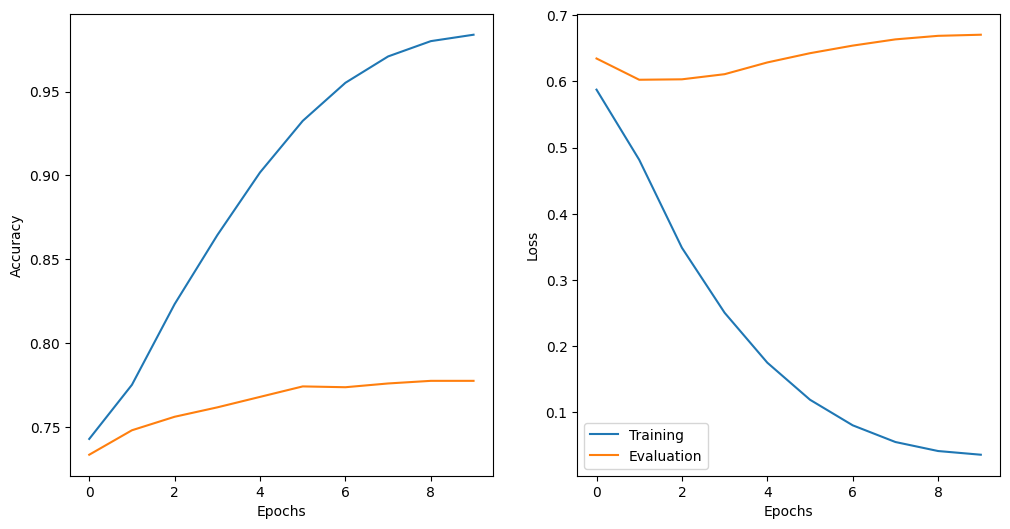

In [45]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
epochs = list(range(len(train_accs)))
axs[0].plot(epochs,train_accs, label = "Training")
axs[0].plot(epochs, val_accs, label = "Evaluation")
axs[1].plot(epochs, train_losses, label = "Training")
axs[1].plot(epochs, val_losses, label = "Evaluation")
axs[0].set_xlabel("Epochs")
axs[1].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Loss")
plt.legend()
plt.savefig('./training_curves.png')
plt.show()

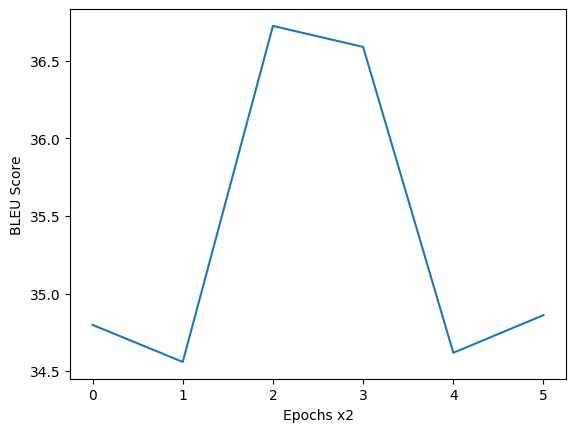

In [46]:
epochs = list(range(len(bleu_scores)))
plt.plot(epochs, bleu_scores)
plt.xlabel("Epochs x2")
plt.ylabel("BLEU Score")
plt.savefig('./bleu_scores.png')
plt.show()

In [ ]:
# best_model = NMT(DIM, NHEAD, SIZE, DROPOUT, FFN, NUM_ENCODERS, NUM_DECODERS )
# best_model.load_state_dict(torch.load("/kaggle/working/model.pth", weights_only=True))
# best_model = best_model.to(DEVICE)
# best_model

In [48]:
def inference(zhs):
    preds = []
    for zh in zhs:
        preds.append(translate_text(zh))
    return preds

In [49]:
zh_private = []
with open(private_path / "private_test.zh", "r", encoding="utf-8") as f:
     zh_private = f.read().splitlines()
vi_private = inference(zh_private)

In [ ]:
len(zh_private), len(vi_private)

In [50]:
zh_private[1], vi_private[1]

('我 现在 在 机场 。', 'Tôi đang ở sân_bay .')

In [51]:
public_submit = pd.DataFrame({
    "tieng_trung": zh_private,
    "tieng_viet": vi_private
})

In [52]:
public_submit.sample(5)

,tieng_trung,tieng_viet
281,我们 需要 减少 预算 。,Chúng_tôi cần giảm chi_phí .
1444,你 不 觉得 你 应该 给 她 买 点 贵重 一 点 的 东西 吗 ？,Bạn không nghĩ bạn nên mua cho cô ta một_số đồ...
1441,你 可以 开会 儿车 吗 ？,có_thể họp xe được không ?
19,"再 不 要 了 , 谢谢 你 。","Không , cảm_ơn ."
930,一百五十 美元 ？,Một trăm năm mươi đô_la phải không ?


In [53]:
public_submit.to_csv("nlp_submission.csv", index=False)

In [54]:
!zip -r "nlp.zip" nlp_submission.csv

updating: nlp_submission.csv (deflated 62%)


In [55]:
torch.save(backbone.state_dict(), "opus.bin")